In [ ]:
from mpi4py import MPI
import gmsh
import math
from pathlib import Path

# For DolfinX import
from dolfinx.io import gmsh as gmshio
from dolfinx.io import XDMFFile

# ------------------------------------------------------------------
# 1. Generate geometry in Gmsh (square with attached semicircular bubble)
# ------------------------------------------------------------------
gmsh.initialize()
gmsh.model.add("square_with_attached_bubble")

# -------------------------
# Parameters
# -------------------------
L = 1.0
V = 0.02
r = math.sqrt(2 * V / math.pi)
lc = 0.02  # mesh size

cx = L / 2
cy = 0.0

# -------------------------
# Points
# -------------------------
p1 = gmsh.model.geo.addPoint(0, 0, 0, lc)  # bottom-left
p2 = gmsh.model.geo.addPoint(L, 0, 0, lc)  # bottom-right
p3 = gmsh.model.geo.addPoint(L, L, 0, lc)  # top-right
p4 = gmsh.model.geo.addPoint(0, L, 0, lc)  # top-left

pc = gmsh.model.geo.addPoint(cx, cy, 0, lc)      # bubble center
pl = gmsh.model.geo.addPoint(cx - r, cy, 0, lc)  # left bubble edge
pr = gmsh.model.geo.addPoint(cx + r, cy, 0, lc)  # right bubble edge
pt = gmsh.model.geo.addPoint(cx, r, 0, lc)       # top of semicircle

# -------------------------
# Lines / arcs
# -------------------------
l_bottom_left = gmsh.model.geo.addLine(p1, pl)
arc_left = gmsh.model.geo.addCircleArc(pl, pc, pt)
arc_right = gmsh.model.geo.addCircleArc(pt, pc, pr)
l_bottom_right = gmsh.model.geo.addLine(pr, p2)
l_right = gmsh.model.geo.addLine(p2, p3)
l_top = gmsh.model.geo.addLine(p3, p4)
l_left = gmsh.model.geo.addLine(p4, p1)

# -------------------------
# Curve loop & surface
# -------------------------
loop = gmsh.model.geo.addCurveLoop([
    l_bottom_left, arc_left, arc_right, l_bottom_right, l_right, l_top, l_left
])
surface = gmsh.model.geo.addPlaneSurface([loop])
gmsh.model.geo.synchronize()

# -------------------------
# Physical groups
# -------------------------
fluid_tag = gmsh.model.addPhysicalGroup(2, [surface])
bubble_tag = gmsh.model.addPhysicalGroup(1, [arc_left, arc_right])
bottom_tag = gmsh.model.addPhysicalGroup(1, [l_bottom_left, l_bottom_right])
top_tag    = gmsh.model.addPhysicalGroup(1, [l_top])
left_tag   = gmsh.model.addPhysicalGroup(1, [l_left])
right_tag  = gmsh.model.addPhysicalGroup(1, [l_right])

# Assign names
gmsh.model.setPhysicalName(2, fluid_tag, "fluid")
gmsh.model.setPhysicalName(1, bubble_tag, "bubble_boundary")
gmsh.model.setPhysicalName(1, bottom_tag, "bottom")
gmsh.model.setPhysicalName(1, top_tag, "top")
gmsh.model.setPhysicalName(1, left_tag, "left")
gmsh.model.setPhysicalName(1, right_tag, "right")

# -------------------------
# Mesh
# -------------------------
gmsh.option.setNumber("Mesh.MshFileVersion", 4.1)
gmsh.model.mesh.generate(2)

out_dir = Path("mesh_output")
out_dir.mkdir(exist_ok=True)
gmsh.write(str(out_dir / "square_bubble_attached.msh"))

# ------------------------------------------------------------------
# 2. Import into DolfinX BEFORE finalize()
# ------------------------------------------------------------------
mesh_data = gmshio.model_to_mesh(
    gmsh.model(),
    MPI.COMM_WORLD,
    rank=0,
    gdim=2
)

dolfinx_mesh = mesh_data.mesh
cell_tags = mesh_data.cell_tags
facet_tags = mesh_data.facet_tags

# ------------------------------------------------------------------
# 3. Export to XDMF
# ------------------------------------------------------------------
with XDMFFile(dolfinx_mesh.comm, out_dir / "square_bubble_mesh.xdmf", "w") as xdmf:
    xdmf.write_mesh(dolfinx_mesh)
    xdmf.write_meshtags(cell_tags, dolfinx_mesh.geometry)
    xdmf.write_meshtags(facet_tags, dolfinx_mesh.geometry)

gmsh.finalize()
print("DolfinX mesh and tags written to:", out_dir)

In [1]:
import dolfinx
import dolfinx.fem as fem
import ufl
from ufl import inner
import numpy as np
from mpi4py import MPI
from basix.ufl import element, mixed_element
from dolfinx.io import gmsh as gmshio
from dolfinx.fem.petsc import NonlinearProblem
from dolfinx.io import VTXWriter

# ─────────────────────────────────────────────
# 1. Load mesh
# ─────────────────────────────────────────────
mesh_data = gmshio.read_from_msh("mesh_output/square_bubble_attached.msh", MPI.COMM_WORLD, 0, gdim=2)
mesh      = mesh_data.mesh
facet_tags = mesh_data.facet_tags

x0   = mesh.geometry.x.copy()
tdim = mesh.topology.dim
fdim = tdim - 1
mesh.topology.create_connectivity(fdim, tdim)

# Bubble center (must match gmsh script)
cx, cy    = 0.5, 0.0
V0_bubble = 0.02
r0        = np.sqrt(2 * V0_bubble / np.pi)

# ─────────────────────────────────────────────
# 2. Mixed function space (ux, uy)
# ─────────────────────────────────────────────
Vx_el = element("Lagrange", mesh.basix_cell(), 1)
V_el  = mixed_element([Vx_el, Vx_el])
V     = fem.functionspace(mesh, V_el)
u     = fem.Function(V)

(ux, uy) = ufl.split(u)
(vx, vy) = ufl.TestFunctions(V)

# ─────────────────────────────────────────────
# 3. Collapsed subspaces + DOF maps
# ─────────────────────────────────────────────
V0, dof_map_0 = V.sub(0).collapse()   # dof_map_0: collapsed → parent indices
V1, dof_map_1 = V.sub(1).collapse()

# Collapsed Functions for writing to VTX
ux_func = fem.Function(V0, name="ux")
uy_func = fem.Function(V1, name="uy")

# BCs — zero ux on left/right
zero_ux = fem.Function(V0)
left_dofs_x  = fem.locate_dofs_topological((V.sub(0), V0), fdim, facet_tags.find(5))
right_dofs_x = fem.locate_dofs_topological((V.sub(0), V0), fdim, facet_tags.find(6))
bc_ux_left   = fem.dirichletbc(zero_ux, left_dofs_x,  V.sub(0))
bc_ux_right  = fem.dirichletbc(zero_ux, right_dofs_x, V.sub(0))

# BC — zero uy on bottom
zero_uy = fem.Function(V1)
bottom_dofs_y = fem.locate_dofs_topological((V.sub(1), V1), fdim, facet_tags.find(3))
bc_uy_bottom  = fem.dirichletbc(zero_uy, bottom_dofs_y, V.sub(1))

# BC — prescribed uy on top (Constant, updated each step)
delta_height = fem.Constant(mesh, dolfinx.default_scalar_type(0.0))
top_dofs_y   = fem.locate_dofs_topological(V.sub(1), fdim, facet_tags.find(4))
bc_uy_top    = fem.dirichletbc(delta_height, top_dofs_y, V.sub(1))

bubble_dofs_x = fem.locate_dofs_topological((V.sub(0), V0), fdim, facet_tags.find(2))
bubble_dofs_y = fem.locate_dofs_topological((V.sub(1), V1), fdim, facet_tags.find(2))

arc_disp_x = fem.Function(V0)   # will be updated each step
arc_disp_y = fem.Function(V1)

bc_arc_x = fem.dirichletbc(arc_disp_x, bubble_dofs_x, V.sub(0))
bc_arc_y = fem.dirichletbc(arc_disp_y, bubble_dofs_y, V.sub(1))

# Precompute the reference arc node positions once (mesh hasn't moved yet)
collapsed_idx_x = bubble_dofs_x[1]   # collapsed-space indices for ux arc DOFs
collapsed_idx_y = bubble_dofs_y[1]   # collapsed-space indices for uy arc DOFs

coords_V0 = V0.tabulate_dof_coordinates()   # shape (n_dofs_V0, 3)
coords_V1 = V1.tabulate_dof_coordinates()

# Unit radial vectors at each arc DOF (computed once from reference geometry)
arc_x_ref_x = coords_V0[collapsed_idx_x, 0] - cx   # x - cx
arc_x_ref_y = coords_V0[collapsed_idx_x, 1] - cy   # y - cy  (for ux dofs)
arc_y_ref_x = coords_V1[collapsed_idx_y, 0] - cx
arc_y_ref_y = coords_V1[collapsed_idx_y, 1] - cy   # (for uy dofs)

# Sanity check: all arc nodes should be at radius r0
assert np.allclose(np.sqrt(arc_x_ref_x**2 + arc_x_ref_y**2), r0, rtol=1e-3), \
    "Arc nodes not at expected radius — check bubble_tag_id or cx/cy/r0"

def update_arc_bcs(r_new):
    """Prescribe radial displacement dr at every arc node."""
    dr = r_new - r0
    # ux component of radial displacement: dr * (x - cx) / r0
    arc_disp_x.x.array[collapsed_idx_x] = dr * arc_x_ref_x / r0
    # uy component of radial displacement: dr * (y - cy) / r0
    arc_disp_y.x.array[collapsed_idx_y] = dr * arc_y_ref_y / r0

bcs = [bc_arc_x, bc_arc_y, bc_ux_left, bc_ux_right, bc_uy_bottom, bc_uy_top]

# ─────────────────────────────────────────────
# 4. Laplace smoothing formulation + solver
# ─────────────────────────────────────────────
F_form = (
      inner(ufl.grad(ux), ufl.grad(vx)) * ufl.dx
    + inner(ufl.grad(uy), ufl.grad(vy)) * ufl.dx
)

problem = NonlinearProblem(F_form, u, bcs=bcs,
    petsc_options_prefix="ale_",
    petsc_options={"ksp_type": "preonly", "pc_type": "lu",
                   "ksp_error_if_not_converged": True},
)

one       = fem.Constant(mesh, dolfinx.default_scalar_type(1.0))
area_form = fem.form(one * ufl.dx(domain=mesh))

# Compute reference area once before the loop
area_ref  = fem.assemble_scalar(area_form)

print(f"Reference mesh area: {area_ref:.6f}")
print(f"  = L^2 + pi*r0^2/2 = {1.0 + np.pi * r0**2 / 2:.6f}  (expected)")
area_ref_check = 1.0 * (1.0 + 0.0) - (np.pi / 2) * r0**2   # at t=0, dh=0
print(f"Expected at t=0:       {area_ref_check:.6f}")
# ─────────────────────────────────────────────
# VTX writer
# ─────────────────────────────────────────────
writer = VTXWriter(MPI.COMM_WORLD, "results/moving_bubble_mesh_pde.bp",
                   [ux_func, uy_func], engine="BP5")

# ─────────────────────────────────────────────
# 6. Time loop
# ─────────────────────────────────────────────
amplitude = 0.5
period    = 5.0
times     = np.linspace(0, 10, 100)

# Storage for plotting
t_hist         = []
area_mesh_hist = []
area_expected_hist = []

area_mesh = area_ref

L = 1.0
L_old = L 
H_old = L
r_old = r0

# ─────────────────────────────────────────────
# 6. Time loop
# ─────────────────────────────────────────────
amplitude = 0.5
period    = 5.0
times     = np.linspace(0, 10, 100)

L = 1.0

# Total area is conserved = initial mesh area (computed before loop)
area_conserved = area_ref
print(f"Target conserved area: {area_conserved:.6f}")

t_hist             = []
area_mesh_hist     = []
area_expected_hist = []


Info    : Reading 'mesh_output/square_bubble_attached.msh'...
Info    : 16 entities
Info    : 3012 nodes
Info    : 6022 elements
Info    : Done reading 'mesh_output/square_bubble_attached.msh'
Reference mesh area: 0.980101
  = L^2 + pi*r0^2/2 = 1.020000  (expected)
Expected at t=0:       0.980000
Target conserved area: 0.980101


In [2]:
def solve_with_area_correction(r_new, tol=1e-12, max_iter=30):
    """Bisect on dh until integrated area == area_conserved."""
    
    # Analytic estimate as starting guess
    H_new_analytic = (area_conserved + (np.pi / 2) * r_new**2) / L
    dh_analytic    = H_new_analytic - L

    # ── Fixed absolute bracket — never collapses near dh=0 ──────────────
    bracket_half = 0.05   # search ± 0.05 around the analytic estimate
    dh_lo = dh_analytic - bracket_half
    dh_hi = dh_analytic + bracket_half

    update_arc_bcs(r_new)

    # Evaluate area at bracket endpoints to confirm we have a sign change
    def area_error(dh_val):
        """Solve, update mesh, return integrated_area - target."""
        delta_height.value = dolfinx.default_scalar_type(dh_val)
        problem.solve()
        ux_vals = u.x.array[dof_map_0]
        uy_vals = u.x.array[dof_map_1]
        mesh.geometry.x[:] = x0 + np.column_stack(
            [ux_vals, uy_vals, np.zeros(len(ux_vals))]
        )
        return fem.assemble_scalar(area_form) - area_conserved

    err_lo = area_error(dh_lo)
    err_hi = area_error(dh_hi)

    assert err_lo * err_hi < 0, (
        f"Bisection bracket has no sign change: "
        f"err({dh_lo:.4f})={err_lo:.2e}, err({dh_hi:.4f})={err_hi:.2e}. "
        f"Widen bracket_half."
    )

    # ── Bisect ───────────────────────────────────────────────────────────
    for i in range(max_iter):
        dh_mid  = 0.5 * (dh_lo + dh_hi)
        err_mid = area_error(dh_mid)

        if abs(err_mid) < tol:
            break

        if err_lo * err_mid < 0:
            dh_hi  = dh_mid
            err_hi = err_mid
        else:
            dh_lo  = dh_mid
            err_lo = err_mid

    return dh_mid

In [3]:

for t in times:
    V_bubble_t = V0_bubble * (1 + amplitude * np.sin(2 * np.pi * t / period))
    r_new      = np.sqrt(2 * V_bubble_t / np.pi)

    # ── Conservation: total area = L*H - (π/2)*r² = const ────────────────
    # Solve for new height H_new, then dh = H_new - L (L is original height)
    # L * H_new - (π/2) * r_new² = area_conserved
    H_new = (area_conserved + (np.pi / 2) * r_new**2) / L
    # dh    = H_new - L   # displacement of top boundary from its original position
    dh = solve_with_area_correction(r_new)

    update_arc_bcs(r_new)
    delta_height.value = dolfinx.default_scalar_type(dh)

    problem.solve()

    ux_vals = u.x.array[dof_map_0]
    uy_vals = u.x.array[dof_map_1]

    ux_func.x.array[:] = ux_vals
    uy_func.x.array[:] = uy_vals

    disp3 = np.column_stack([ux_vals, uy_vals, np.zeros(len(ux_vals))])
    mesh.geometry.x[:] = x0 + disp3

    # ── Verify ────────────────────────────────────────────────────────────
    area_mesh     = fem.assemble_scalar(area_form)
    area_expected = L * H_new - (np.pi / 2) * r_new**2  # = area_conserved by construction

    t_hist.append(t)
    area_mesh_hist.append(area_mesh)
    area_expected_hist.append(area_expected)

    print(f"t={t:.2f}  r={r_new:.5f}  H_new={H_new:.6f}  dh={dh:+.6f}  "
          f"area_mesh={area_mesh:.6f}  target={area_conserved:.6f}  "
          f"err={area_mesh - area_conserved:+.2e}")

    writer.write(t)

writer.close()

t=0.00  r=0.11284  H_new=1.000101  dh=-0.000000  area_mesh=0.980101  target=0.980101  err=-1.46e-11
t=0.10  r=0.11635  H_new=1.001367  dh=+0.001260  area_mesh=0.980101  target=0.980101  err=+6.29e-11
t=0.20  r=0.11971  H_new=1.002613  dh=+0.002499  area_mesh=0.980101  target=0.980101  err=+7.48e-11
t=0.30  r=0.12288  H_new=1.003818  dh=+0.003698  area_mesh=0.980101  target=0.980101  err=-5.95e-11
t=0.40  r=0.12581  H_new=1.004963  dh=+0.004837  area_mesh=0.980101  target=0.980101  err=+8.17e-11
t=0.51  r=0.12848  H_new=1.006030  dh=+0.005899  area_mesh=0.980101  target=0.980101  err=+2.34e-11
t=0.61  r=0.13086  H_new=1.007002  dh=+0.006866  area_mesh=0.980101  target=0.980101  err=+8.39e-11
t=0.71  r=0.13294  H_new=1.007863  dh=+0.007722  area_mesh=0.980101  target=0.980101  err=-1.90e-11
t=0.81  r=0.13469  H_new=1.008599  dh=+0.008454  area_mesh=0.980101  target=0.980101  err=-7.89e-11
t=0.91  r=0.13610  H_new=1.009198  dh=+0.009050  area_mesh=0.980101  target=0.980101  err=+5.22e-11


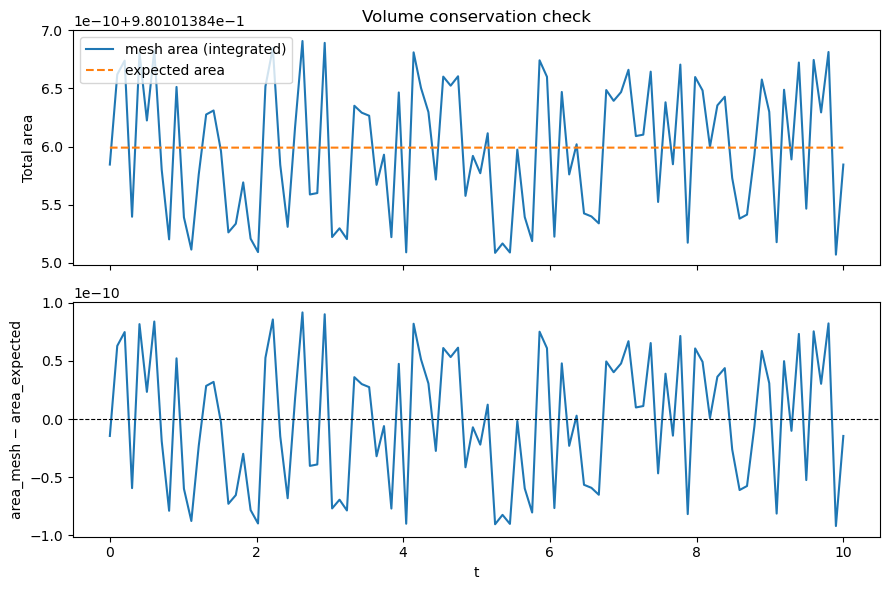

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(t_hist, area_mesh_hist,     label="mesh area (integrated)")
axes[0].plot(t_hist, area_expected_hist, "--", label="expected area")
axes[0].set_ylabel("Total area")
axes[0].legend()
axes[0].set_title("Volume conservation check")

error = np.array(area_mesh_hist) - np.array(area_expected_hist)
axes[1].plot(t_hist, error)
axes[1].axhline(0, color="k", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("area_mesh − area_expected")
axes[1].set_xlabel("t")

plt.tight_layout()
plt.savefig("results/volume_conservation.png", dpi=150)
plt.show()